In [3]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
tomates = pd.read_csv("data/tomates.csv")
tomates.head()

,Tratamiento,Promedio,Bloque
0,TQ,54.7,1
1,TQ,51.2,2
2,TQ,53.3,3
3,TQ,56.9,4
4,TQ,53.6,5


In [7]:
resumen = tomates.groupby('Tratamiento')['Promedio'].agg(['mean', 'std'])

In [ ]:
orden = tomates.groupby('Tratamiento')['Promedio'].mean().sort_values()

Tratamiento
T      51.04
TQ     53.94
AZ2    57.94
AZ1    59.88
Name: Promedio, dtype: float64

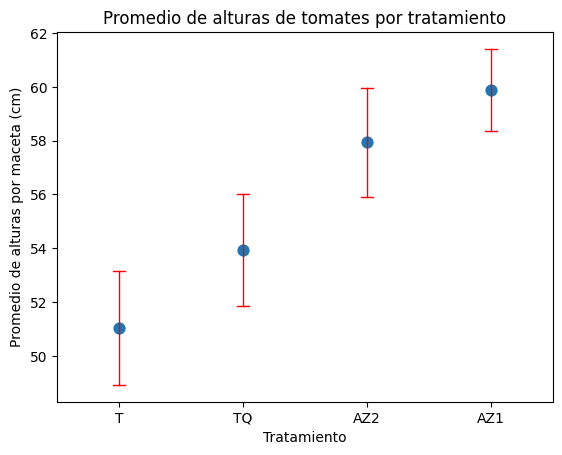

In [21]:
sns.pointplot(data=tomates, 
              x="Tratamiento", 
              y="Promedio", 
              errorbar="sd", 
              linestyles="none", 
              order=orden.index,
              capsize=0.1,
              err_kws={"linewidth":1, "color":"red"})
plt.title("Promedio de alturas de tomates por tratamiento")
plt.xlabel("Tratamiento")
plt.ylabel("Promedio de alturas por maceta (cm)")
plt.show()

In [4]:
tomates_lm = ols('Promedio ~ Tratamiento', data=tomates).fit()
tomates_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     20.66
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           9.47e-06
Time:                        07:53:28   Log-Likelihood:                -39.537
No. Observations:                  20   AIC:                             87.07
Df Residuals:                      16   BIC:                             91.06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             59.8800      0.874     68.550      0.000      58.028      61.732
Tratamiento[T.AZ2]    -1.9400      1.235     -1.570      0.136      -4.559       0.679
Tratamiento[T.T]      -8.8400      1.235     -7.156      0.000     -11.459      -6.221
Tratamiento[T.TQ]     -5.9400      1.235     -4.808      0.000      -8.559      -3.321
==============================================================================
Omnibus:                        2.378   Durbin-Watson:                   2.755
Prob(Omnibus):                  0.304   Jarque-Bera (JB):                1.108
Skew:                           0.006   Prob(JB):                        0.575
Kurtosis:                       1.847   Cond. No.                         4.79
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [5]:
sm.stats.anova_lm(tomates_lm, typ=2)

,sum_sq,df,F,PR(>F)
Tratamiento,236.516,3.0,20.664089,0.000009
Residual,61.044,16.0,NaN,NaN
